#  Сегментация изображений

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* https://www.kaggle.com/datasets/rajkumarl/people-clothing-segmentation/data
* https://pyimagesearch.com/2021/11/08/u-net-training-image-segmentation-models-in-pytorch/
* https://amaarora.github.io/posts/2020-09-13-unet.html
* https://pytorch.org/docs/stable/generated/torch.nn.ConvTranspose2d.html
* https://medium.com/apache-mxnet/transposed-convolutions-explained-with-ms-excel-52d13030c7e8
* https://github.com/vdumoulin/conv_arithmetic/blob/master/README.md
* https://huggingface.co/docs/transformers/model_doc/segformer
* https://www.kaggle.com/code/damianpanek/segformerb0-people-clothing-segmentation

## Задачи для совместного разбора

1\. Рассмотрите пример работы слоя `ConvTranspose2d`.

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Опишите датасет `ClothesSegmentationDataset`. Реализуйте `__getitem__` таким образом, чтобы он возвращал два элемента: тензор с изображением и тензор с маской. Маска должна быть представлена трехмерным тензором целых чисел. Предусмотрите возможность передавать извне при создании датасета набор преобразований для изображений и масок. Создайте объект датасета и выведите на экран форму и типы одного изображения и его маски.

- [ ] Проверено на семинаре

In [1]:
import zipfile
import os
import torch
from torch.utils.data import Dataset
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image

In [21]:
zip_path = "C://Users//robucks//Desktop//62//archive.zip"
extract_dir = "C://Users//robucks//Desktop//62//archive_folder"

In [23]:
if not os.path.exists(extract_dir):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

In [25]:
class ClothesSegmentationDataset(Dataset):
    def __init__(self, images_dir, masks_dir, image_files, mask_files, transform=None):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.image_files = image_files
        self.mask_files = mask_files
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image_path = os.path.join(self.images_dir, self.image_files[idx])
        mask_path = os.path.join(self.masks_dir, self.mask_files[idx])

        image = Image.open(image_path).convert('RGB')
        mask = Image.open(mask_path).convert('L')

        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)
            mask = (mask * 255).long().squeeze(0)  # Преобразуем в целые числа

        return image, mask

In [30]:
jpeg_images_dir = 'C://Users//robucks//Desktop//62//archive_folder//jpeg_images//IMAGES'
jpeg_masks_dir = 'C://Users//robucks//Desktop//62//archive_folder//jpeg_masks//MASKS'

image_files = sorted(os.listdir(jpeg_images_dir))
mask_files = sorted(os.listdir(jpeg_masks_dir))

transform = transforms.Compose([
    transforms.ToTensor(),
])

# Создание датасета
dataset = ClothesSegmentationDataset(jpeg_images_dir, jpeg_masks_dir, image_files, mask_files, transform)

# Извлечение одного элемента
image, mask = dataset[0]

print(f"Image shape: {image.shape}, Image type: {image.dtype}")
print(f"Mask shape: {mask.shape}, Mask type: {mask.dtype}")

Image shape: torch.Size([3, 825, 550]), Image type: torch.float32
Mask shape: torch.Size([825, 550]), Mask type: torch.int64


<p class="task" id="2"></p>

2\. Напишите функцию `show_image_with_mask`, которая выводит рядом два изображения: фотографию и маску. Продемонстрируйте работу функции, взяв один пример из созданного датасета.

- [ ] Проверено на семинаре

In [33]:
def show_image_with_mask(image, mask):
    """
    Отображает изображение и маску рядом.

    :param image: Изображение (PyTorch Tensor)
    :param mask: Маска (PyTorch Tensor)
    """
    # Преобразуем из (C, H, W) в (H, W, C)
    image = image.permute(1, 2, 0).cpu().numpy()

    # Масштабируем маску в диапазон [0, 255] для корректной визуализации
    mask = mask.cpu().numpy()
    mask = (mask * (255 // mask.max())).astype(np.uint8)  # Масштабируем значения маски

    # Создаем подграфики для отображения
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Отображаем изображение
    axes[0].imshow(image)
    axes[0].set_title("Image")
    axes[0].axis('off')  # Отключаем оси

    # Отображаем маску
    axes[1].imshow(mask, cmap='jet')  # Используем cmap для цветной маски
    axes[1].set_title("Mask")
    axes[1].axis('off')  # Отключаем оси

    plt.show()

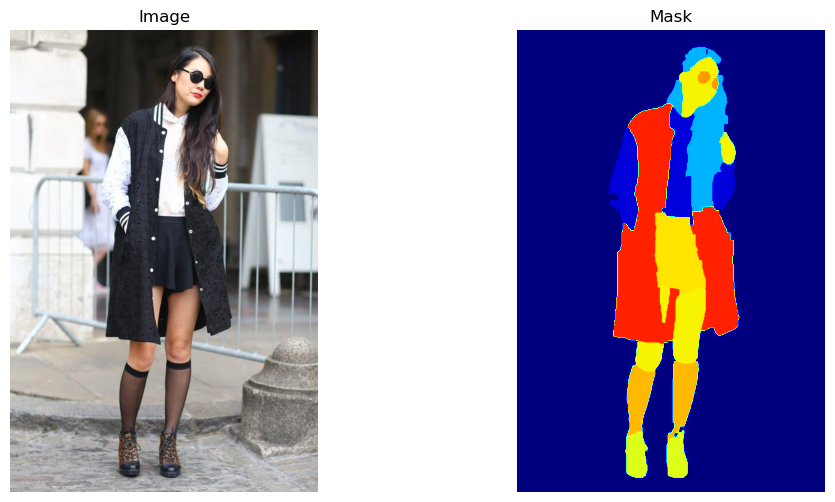

In [35]:
image, mask = dataset[0]

show_image_with_mask(image, mask)

<p class="task" id="3"></p>

3\. Реализуйте архитектуру U-Net. Реализуйте модель таким образом, чтобы на выходе для каждого изображения получался тензор размера `n_classes x h x w`, где `n_classes` - количество уникальных значений в масках, а `h` и `w` - размер исходного изображения. Возьмите один пример из набора данных и пропустите его через сеть. Выведите форму полученного результата на экран.

- [ ] Проверено на семинаре

In [38]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [40]:
class UNet(nn.Module):
    def __init__(self, n_classes: int):
        super(UNet, self).__init__()

        self.encoder1 = self.conv_block(3, 64)
        self.encoder2 = self.conv_block(64, 128)
        self.encoder3 = self.conv_block(128, 256)
        self.encoder4 = self.conv_block(256, 512)

        self.middle = self.conv_block(512, 1024)

        self.decoder4 = self.upconv_block(1024, 512)
        self.decoder3 = self.upconv_block(512, 256)
        self.decoder2 = self.upconv_block(256, 128)
        self.decoder1 = self.upconv_block(128, 64)

        self.final_conv = nn.Conv2d(64, n_classes, kernel_size=1)

    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

    def upconv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        e1 = self.encoder1(x)
        e2 = self.encoder2(e1)
        e3 = self.encoder3(e2)
        e4 = self.encoder4(e3)

        m = self.middle(e4)

        d4 = self.decoder4(m)
        d3 = self.decoder3(d4)
        d2 = self.decoder2(d3)
        d1 = self.decoder1(d2)

        output = self.final_conv(d1)

        # Восстанавливаем размерность до исходного
        output = F.interpolate(output, size=x.shape[2:], mode='bilinear', align_corners=False)

        return output

<p class="task" id="4"></p>

4\.  Разбейте набор данных на обучающее и валидационное множество. Обучите модель U-Net для сегментации изображения. Во время обучения выводите на экран значения функции потерь и точности прогнозов на обучающем и валидационном множестве. Обратите внимание, что выборка является несбалансированной. При расчете функции потерь примените любую известную вам технику для работы с несбалансированными выборками.

При создании датасета допускается использовать преобразования, уменьшающие размер изображений (для ускорения процесса обучения).

Используя обученную модель, получите предсказания для нескольких изображений и отрисуйте их.
- [ ] Проверено на семинаре

In [43]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

In [44]:
image_files = sorted(os.listdir(jpeg_images_dir))
mask_files = sorted(os.listdir(jpeg_masks_dir))

train_images, val_images, train_masks, val_masks = train_test_split(
    image_files, mask_files, test_size=0.2, random_state=42
)

In [45]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

# Создание обучающего и валидационного датасетов
train_dataset = ClothesSegmentationDataset(jpeg_images_dir, jpeg_masks_dir, train_images, train_masks, transform)
val_dataset = ClothesSegmentationDataset(jpeg_images_dir, jpeg_masks_dir, val_images, val_masks, transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [46]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [51]:
device

device(type='cpu')

In [53]:
n_classes = 59
model = UNet(n_classes=n_classes).to(device)
optimizer = optim.Adam(model.parameters())
criterion = nn.CrossEntropyLoss()

In [57]:
epochs = 10
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()

        # Прямой проход
        outputs = model(images)

        # Вычисление функции потерь
        loss = criterion(outputs, masks)
        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        # Подсчёт точности
        _, predicted = torch.max(outputs.data, 1)
        total_train += masks.numel()
        correct_train += (predicted == masks).sum().item()

    train_loss /= len(train_loader)
    train_accuracy = 100 * correct_train / total_train

    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    # Оценка на валидационной выборке
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)

            # Прямой проход
            outputs = model(images)

            # Вычисление функции потерь
            loss = criterion(outputs, masks)
            val_loss += loss.item()

            # Подсчёт точности
            _, predicted = torch.max(outputs.data, 1)
            total_val += masks.numel()
            correct_val += (predicted == masks).sum().item()

    val_loss /= len(val_loader)
    val_accuracy = 100 * correct_val / total_val

    print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%, "
          f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%")

Epoch [1/10], Train Loss: 1.2007, Train Accuracy: 74.62%, Validation Loss: 1.1315, Validation Accuracy: 74.86%
Epoch [2/10], Train Loss: 1.1187, Train Accuracy: 74.62%, Validation Loss: 1.0981, Validation Accuracy: 74.86%
Epoch [3/10], Train Loss: 1.0655, Train Accuracy: 75.73%, Validation Loss: 1.0701, Validation Accuracy: 75.84%
Epoch [4/10], Train Loss: 1.0469, Train Accuracy: 75.81%, Validation Loss: 1.0700, Validation Accuracy: 75.79%
Epoch [5/10], Train Loss: 1.0396, Train Accuracy: 75.82%, Validation Loss: 1.0315, Validation Accuracy: 76.01%
Epoch [6/10], Train Loss: 1.0066, Train Accuracy: 75.99%, Validation Loss: 0.9992, Validation Accuracy: 76.14%
Epoch [7/10], Train Loss: 0.9814, Train Accuracy: 76.23%, Validation Loss: 0.9829, Validation Accuracy: 76.24%
Epoch [8/10], Train Loss: 0.9747, Train Accuracy: 76.58%, Validation Loss: 0.9807, Validation Accuracy: 76.63%
Epoch [9/10], Train Loss: 0.9554, Train Accuracy: 76.75%, Validation Loss: 0.9551, Validation Accuracy: 76.75%
E

In [59]:
for epoch in range(40):
    model.train()
    train_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()

        # Прямой проход
        outputs = model(images)

        # Вычисление функции потерь
        loss = criterion(outputs, masks)
        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        # Подсчёт точности
        _, predicted = torch.max(outputs.data, 1)
        total_train += masks.numel()
        correct_train += (predicted == masks).sum().item()

    train_loss /= len(train_loader)
    train_accuracy = 100 * correct_train / total_train

    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    # Оценка на валидационной выборке
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)

            # Прямой проход
            outputs = model(images)

            # Вычисление функции потерь
            loss = criterion(outputs, masks)
            val_loss += loss.item()

            # Подсчёт точности
            _, predicted = torch.max(outputs.data, 1)
            total_val += masks.numel()
            correct_val += (predicted == masks).sum().item()

    val_loss /= len(val_loader)
    val_accuracy = 100 * correct_val / total_val

    print(f"Epoch [{epoch+11}/{epochs}], Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%, "
          f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%")

Epoch [11/10], Train Loss: 0.9348, Train Accuracy: 76.98%, Validation Loss: 0.9373, Validation Accuracy: 76.90%
Epoch [12/10], Train Loss: 0.9286, Train Accuracy: 77.07%, Validation Loss: 0.9393, Validation Accuracy: 77.06%
Epoch [13/10], Train Loss: 0.9186, Train Accuracy: 77.20%, Validation Loss: 0.9221, Validation Accuracy: 77.22%
Epoch [14/10], Train Loss: 0.9146, Train Accuracy: 77.30%, Validation Loss: 0.9184, Validation Accuracy: 77.30%
Epoch [15/10], Train Loss: 0.9076, Train Accuracy: 77.49%, Validation Loss: 0.9181, Validation Accuracy: 77.24%
Epoch [16/10], Train Loss: 0.9128, Train Accuracy: 77.36%, Validation Loss: 0.9120, Validation Accuracy: 77.43%
Epoch [17/10], Train Loss: 0.9030, Train Accuracy: 77.54%, Validation Loss: 0.9069, Validation Accuracy: 77.52%
Epoch [18/10], Train Loss: 0.8996, Train Accuracy: 77.61%, Validation Loss: 0.9062, Validation Accuracy: 77.53%
Epoch [19/10], Train Loss: 0.8898, Train Accuracy: 77.81%, Validation Loss: 0.9018, Validation Accuracy:

KeyboardInterrupt: 

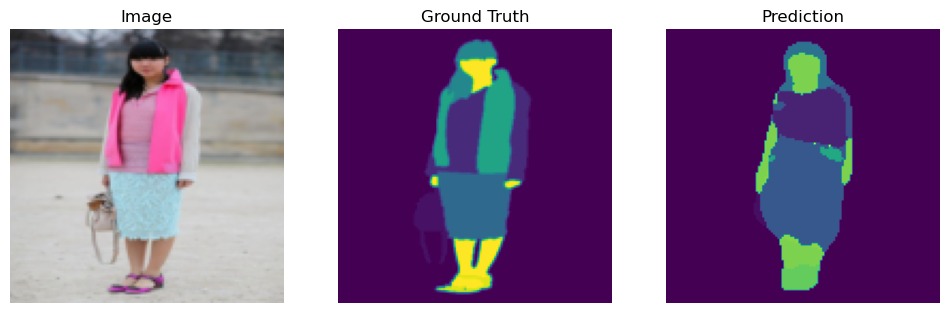

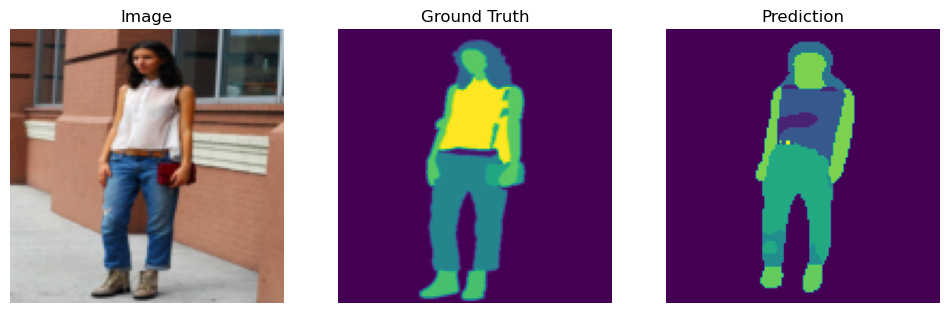

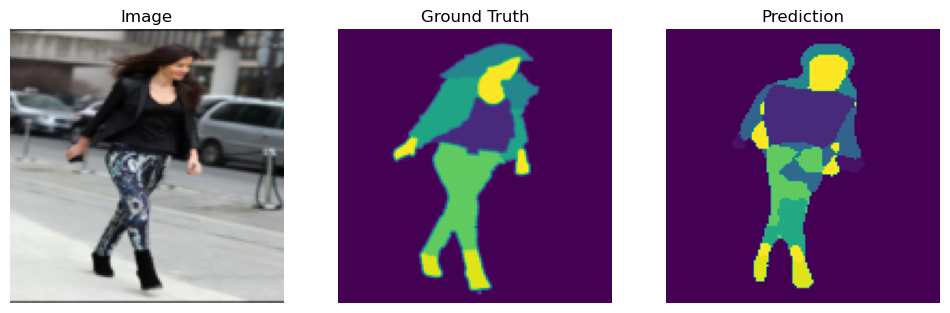

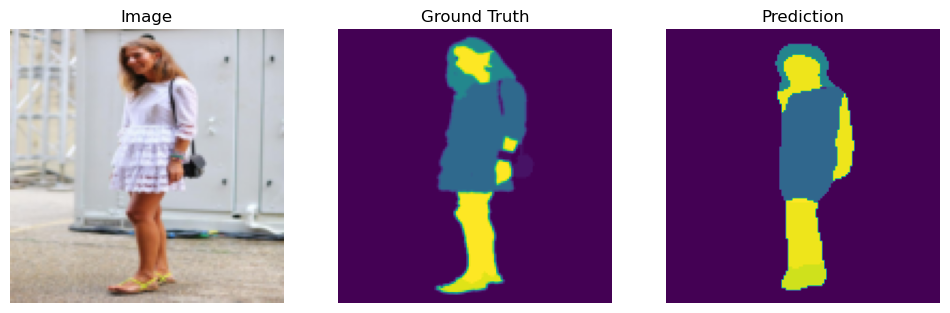

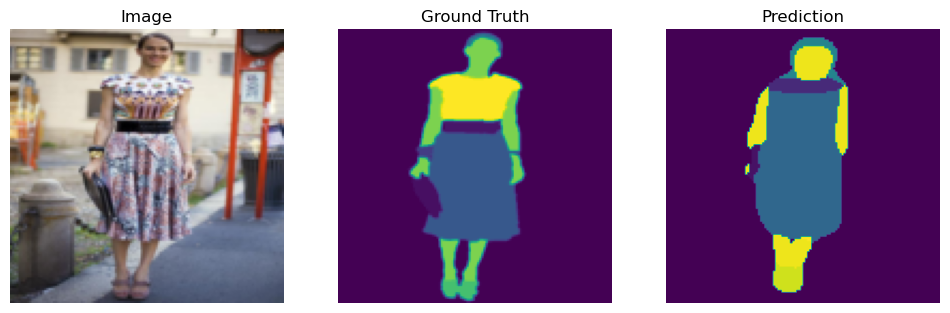

In [64]:
model.eval()  # Переводим модель в режим оценки (без обновлений весов)
with torch.no_grad():  # Отключаем вычисление градиентов для экономии памяти
    outputs = model(images.to(device))  # Передаем изображения в модель (убедитесь, что они на правильном устройстве)
    preds = torch.argmax(outputs, dim=1)  # Получаем предсказания (наибольшее значение по каждому пикселю)

# Отображение изображений и их предсказаний
def show_images(images, masks, preds, n=5):
    """
    Отображение изображений, масок и предсказаний.
    """
    for i in range(n):
        fig, ax = plt.subplots(1, 3, figsize=(12, 4))
        
        # Исходное изображение
        ax[0].imshow(images[i].cpu().permute(1, 2, 0))  # Переводим из (C, H, W) в (H, W, C)
        ax[0].set_title('Image')
        ax[0].axis('off')
        
        # Истинная маска
        ax[1].imshow(masks[i].cpu())  # Маска как черно-белое изображение
        ax[1].set_title('Ground Truth')
        ax[1].axis('off')
        
        # Предсказанная маска
        ax[2].imshow(preds[i].cpu())  # Предсказания как черно-белое изображение
        ax[2].set_title('Prediction')
        ax[2].axis('off')
        
        plt.show()

# Пример использования
show_images(images, masks, preds, n=5)

<p class="task" id="5"></p>

5\.  Обучите модуль `SegformerForSemanticSegmentation` из пакета `transformers` для сегментации изображения. Во время обучения выводите на экран значения функции потерь и точности прогнозов на обучающем и валидационном множестве. Для оптимизации используйте значение функции потерь, которое возвращает вам модель.

Используя обученную модель, получите предсказания для нескольких изображений и отрисуйте их.
- [ ] Проверено на семинаре